### Import Libraries

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import urllib.request
import gc
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully.")
print(f"TensorFlow version: {tf.__version__}")

Libraries imported successfully.
TensorFlow version: 2.20.0


### Load and Explore Text Data

In [ ]:
url = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"
file_path = "shakespeare.txt"

urllib.request.urlretrieve(url, file_path)

with open(file_path, 'r', encoding='utf-8') as f:
    text = f.read()

print("=" * 60)
print("TEXT DATA INFORMATION")
print("=" * 60)
print(f"Total characters: {len(text):,}")
print(f"First 400 characters:\n{text[:400]}")

TEXT DATA INFORMATION
Total characters: 1,115,394
First 400 characters:
First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.

All:
We know't, we know't.

First Citizen:
Let us kill him, and we'll have corn at our own price.
Is't a verdict?

All:
No more talking on't; let it 


### Create Character Vocabulary

In [ ]:
chars = sorted(list(set(text)))
vocab_size = len(chars)

print("=" * 60)
print("VOCABULARY")
print("=" * 60)
print(f"Unique characters: {vocab_size}")
print(f"Characters: {''.join(chars)}")

char_to_idx = {ch: i for i, ch in enumerate(chars)}
idx_to_char = {i: ch for i, ch in enumerate(chars)}

print(f"\nVocabulary size for model: {vocab_size}")

VOCABULARY
Unique characters: 65
Characters: 
 !$&',-.3:;?ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz

Vocabulary size for model: 65


### Create Training Sequences

In [ ]:
SEQ_LENGTH = 100
STEP = 3

sequences = []
next_chars = []

for i in range(0, len(text) - SEQ_LENGTH, STEP):
    sequences.append(text[i:i + SEQ_LENGTH])
    next_chars.append(text[i + SEQ_LENGTH])

    # Limit sequences to prevent memory issues
    if len(sequences) >= 40000:
        break

print("=" * 60)
print("SEQUENCE CREATION")
print("=" * 60)
print(f"Sequence length: {SEQ_LENGTH}")
print(f"Total sequences: {len(sequences):,}")
print(f"Sample input: {sequences[0][:80]}...")
print(f"Sample target: '{next_chars[0]}'")

SEQUENCE CREATION
Sequence length: 100
Total sequences: 40,000
Sample input: First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak....
Sample target: ' '


### Vectorize Sequences

In [ ]:
print("Vectorizing sequences...")

X = np.zeros((len(sequences), SEQ_LENGTH, vocab_size), dtype=np.float32)
y = np.zeros((len(sequences), vocab_size), dtype=np.float32)

for i, seq in enumerate(sequences):
    for t, char in enumerate(seq):
        X[i, t, char_to_idx[char]] = 1
    y[i, char_to_idx[next_chars[i]]] = 1

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

# Train/validation split
split_idx = int(0.9 * len(X))
X_train, X_val = X[:split_idx], X[split_idx:]
y_train, y_val = y[:split_idx], y[split_idx:]

print(f"Training samples: {len(X_train):,}")
print(f"Validation samples: {len(X_val):,}")

Vectorizing sequences...
X shape: (40000, 100, 65)
y shape: (40000, 65)
Training samples: 36,000
Validation samples: 4,000


### Build LSTM Model

In [ ]:
def create_lstm_model(vocab_size, seq_length):
    model = Sequential([
        LSTM(128, input_shape=(seq_length, vocab_size), return_sequences=True),
        Dropout(0.2),
        LSTM(128),
        Dropout(0.2),
        Dense(vocab_size, activation='softmax')
    ])

    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

model = create_lstm_model(vocab_size, SEQ_LENGTH)

print("=" * 60)
print("LSTM MODEL ARCHITECTURE")
print("=" * 60)
model.summary()
print(f"\nTotal parameters: {model.count_params():,}")

LSTM MODEL ARCHITECTURE


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 100, 128)       │        99,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 100, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 128)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 65)             │         8,385 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 239,297 (934.75 KB)

 Trainable params: 239,297 (934.75 KB)

 Non-trainable params: 0 (0.00 B)


Total parameters: 239,297


### Train the Model

In [ ]:
EPOCHS = 50
BATCH_SIZE = 128

print("=" * 60)
print("TRAINING LSTM MODEL")
print("=" * 60)
print(f"Epochs: {EPOCHS}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Training samples: {len(X_train):,}")
print(f"Validation samples: {len(X_val):,}\n")

history = model.fit(
    X_train, y_train,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_data=(X_val, y_val),
    verbose=1
)

print("\nTraining completed for all 50 epochs.")
print(f"Final validation accuracy: {history.history['val_accuracy'][-1]:.4f}")

TRAINING LSTM MODEL
Epochs: 50
Batch size: 128
Training samples: 36,000
Validation samples: 4,000

Epoch 1/50
282/282 ━━━━━━━━━━━━━━━━━━━━ 6s 21ms/step - accuracy: 0.5216 - loss: 1.5816 - val_accuracy: 0.4990 - val_loss: 1.7026
Epoch 2/50
282/282 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - accuracy: 0.5248 - loss: 1.5640 - val_accuracy: 0.4960 - val_loss: 1.7091
Epoch 3/50
282/282 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - accuracy: 0.5299 - loss: 1.5508 - val_accuracy: 0.5013 - val_loss: 1.6962
Epoch 4/50
282/282 ━━━━━━━━━━━━━━━━━━━━ 10s 20ms/step - accuracy: 0.5303 - loss: 1.5372 - val_accuracy: 0.4905 - val_loss: 1.7059
Epoch 5/50
282/282 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - accuracy: 0.5349 - loss: 1.5259 - val_accuracy: 0.5002 - val_loss: 1.7029
Epoch 6/50
282/282 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - accuracy: 0.5408 - loss: 1.5050 - val_accuracy: 0.4945 - val_loss: 1.7148
Epoch 7/50
282/282 ━━━━━━━━━━━━━━━━━━━━ 10s 20ms/step - accuracy: 0.5421 - loss: 1.4928 - val_accuracy: 0.4967 - val_loss: 1.7

### Plot Training History


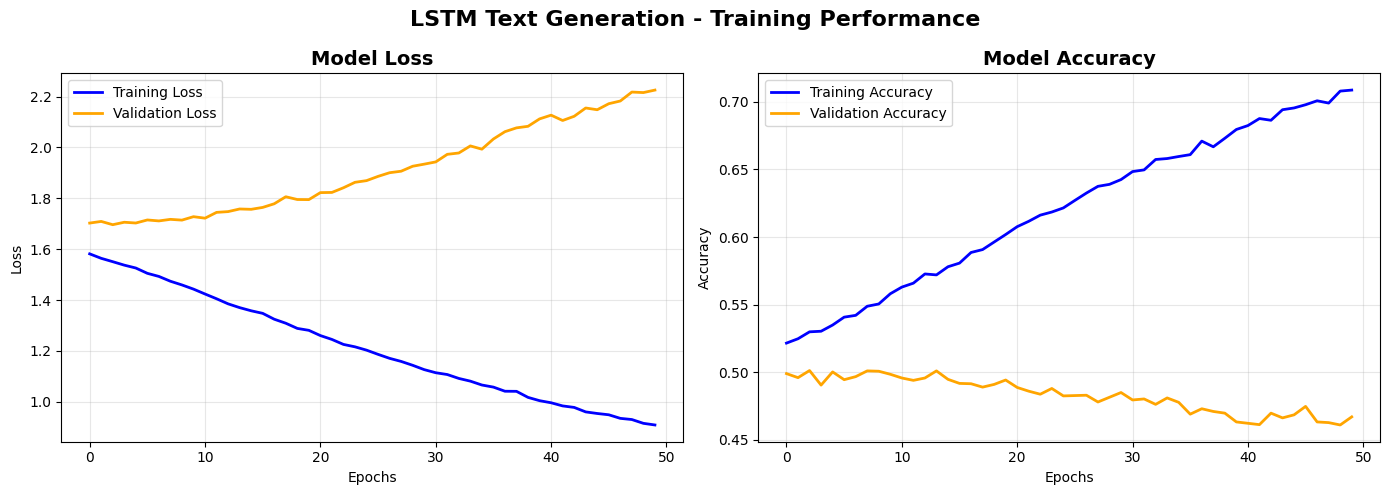

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['loss'], label='Training Loss', color='blue', linewidth=2)
axes[0].plot(history.history['val_loss'], label='Validation Loss', color='orange', linewidth=2)
axes[0].set_title('Model Loss', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history['accuracy'], label='Training Accuracy', color='blue', linewidth=2)
axes[1].plot(history.history['val_accuracy'], label='Validation Accuracy', color='orange', linewidth=2)
axes[1].set_title('Model Accuracy', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('LSTM Text Generation - Training Performance', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('lstm_training_history.png', dpi=150)
plt.show()

### Text Generation Function

In [ ]:
def generate_text(model, seed_text, num_chars=300, temperature=1.0):
    """
    Generate text using trained LSTM model.

    Parameters:
    - seed_text: Starting text string
    - num_chars: Number of characters to generate
    - temperature: Controls randomness (0.5=conservative, 1.0=balanced, 1.2=creative)
    """
    generated = seed_text

    for _ in range(num_chars):
        current_seq = generated[-SEQ_LENGTH:]

        x_pred = np.zeros((1, SEQ_LENGTH, vocab_size))
        for t, char in enumerate(current_seq):
            if char in char_to_idx:
                x_pred[0, t, char_to_idx[char]] = 1

        predictions = model.predict(x_pred, verbose=0)[0]

        # Apply temperature
        predictions = np.log(predictions + 1e-7) / temperature
        exp_preds = np.exp(predictions)
        predictions = exp_preds / np.sum(exp_preds)

        next_idx = np.random.choice(range(vocab_size), p=predictions)
        generated += idx_to_char[next_idx]

    return generated

print("Text generation function created.")
print(f"Uses sequence length: {SEQ_LENGTH}")

Text generation function created.
Uses sequence length: 100


### Generate Text Samples

In [ ]:
print("=" * 70)
print("TEXT GENERATION RESULTS")
print("=" * 70)

test_seeds = [
    "ROMEO: ",
    "HAMLET: To be ",
    "KING: I have ",
    "JULIET: My "
]

for seed in test_seeds:
    print(f"\n--- Seed: '{seed}' (temperature=1.0) ---")
    result = generate_text(model, seed, num_chars=250, temperature=1.0)
    print(result)
    print("-" * 70)

# Save to file
with open('generated_text.txt', 'w') as f:
    f.write("LSTM TEXT GENERATION RESULTS\n")
    f.write("=" * 50 + "\n\n")
    for seed in test_seeds:
        f.write(f"Seed: {seed}\n")
        f.write(generate_text(model, seed, num_chars=200, temperature=1.0))
        f.write("\n\n" + "-" * 50 + "\n\n")

print("\nGenerated text saved to 'generated_text.txt'")

TEXT GENERATION RESULTS

--- Seed: 'ROMEO: ' (temperature=1.0) ---
ROMEO: vgyaut,eo-setaeywi;,y,nvrs
c,peiteaasa  e' mssy ,cy ii
a'niioe'et
 aeyiys,?eao leo;iie.eemo,s 'tood you go, out os, reop, lear,
That go guthous this foldy, so a his pore
Thou speat you sir.

SecondiCiities:
Hat, the Valst thes this fault of the peopl
----------------------------------------------------------------------

--- Seed: 'HAMLET: To be ' (temperature=1.0) ---
HAMLET: To be '' oeoee ?'o' itii 
,eyeyaet, ,,p'aiiip;,aooesan;spet'yiyt cei' 

 y''le,tttl   iiatcnes a gondret; and that I will bood And enters
At all's your puttite and wis proging 'tring my not.

AEFile:
I't, we'll enenion foithing prof he it power they
Lols p
----------------------------------------------------------------------

--- Seed: 'KING: I have ' (temperature=1.0) ---
KING: I have eg of'aiiy, t'npi pia:''
 ocisaee i'a
l'h.cieee
ivciy;iuli 'D'wi 
g,i.oyicid.eeasmeeo' mat, the huss tho fand of their
Willly his cainor city merat I which 

###  Temperature Comparison

In [ ]:
seed = "ROMEO: "

print("=" * 70)
print("TEMPERATURE COMPARISON (Same Seed)")
print("=" * 70)

temperatures = [0.5, 0.8, 1.0, 1.2]

for temp in temperatures:
    result = generate_text(model, seed, num_chars=150, temperature=temp)
    print(f"\n--- Temperature: {temp} ---")
    print(f"{result[:200]}...")
    print("-" * 50)

print("\nTemperature Guide:")
print("  0.5: More predictable, repetitive, conservative")
print("  1.0: Balanced, creative, coherent")
print("  1.2: More random, surprising, less coherent")

TEMPERATURE COMPARISON (Same Seed)

--- Temperature: 0.5 ---
ROMEO: eeyieteyeetitaeeaanicocTrrc
ii eeeot'' Feieyenctnyeeeen' epeeu.i i nemn''eeae  leesee,,!!iy!''l Is marking as you,
The manst he hard to partith, the c...
--------------------------------------------------

--- Temperature: 0.8 ---
ROMEO: eee ''ticc
ei'epet r.;ttyoiem ;,t,
'vepss,t p,yecio:odo,
ei ef.i'Ro's,,e's' n, ',-
'',,t,iiets, are it not soull partielt; whence, they
wort his shall...
--------------------------------------------------

--- Temperature: 1.0 ---
ROMEO: o-'ieeca
.tf
.,n c c h'leeehye,atyo ?tei
o,b.eai.ryenttCcub ti ?, e.ieie ihhieinbe feie! ' i mourt,
Well seive the mrerss 'oriline afmith:
It ser a pa...
--------------------------------------------------

--- Temperature: 1.2 ---
ROMEO: ',fnipnot
idm.,:yet
aya' p,,uafy?la''ny,eni i,dst h.t;pee
 'Udn;p!,,l.i,liaiii.ieAefeefoioee; bear, lets thou go : empecay.

MENENIUS:
give all all ev...
--------------------------------------------------

Temperature 

### Final Evaluation Summary

In [ ]:
print("=" * 70)
print("PROJECT SUMMARY")
print("=" * 70)

print(f"\nDataset:")
print(f"  - Source: Shakespeare's works")
print(f"  - Total characters: {len(text):,}")
print(f"  - Unique characters: {vocab_size}")

print(f"\nPreprocessing:")
print(f"  - Sequence length: {SEQ_LENGTH}")
print(f"  - Training sequences: {len(X_train):,}")
print(f"  - Validation sequences: {len(X_val):,}")

print(f"\nModel Architecture:")
print(f"  - LSTM Layer 1: 128 units (return_sequences=True)")
print(f"  - Dropout: 0.2")
print(f"  - LSTM Layer 2: 128 units")
print(f"  - Dropout: 0.2")
print(f"  - Dense Output: {vocab_size} units (softmax)")
print(f"  - Total parameters: {model.count_params():,}")

print(f"\nTraining Results:")
print(f"  - Best validation accuracy: {max(history.history['val_accuracy']):.4f}")
print(f"  - Best validation loss: {min(history.history['val_loss']):.4f}")

print(f"\nGenerated Files:")
print(f"  - lstm_training_history.png")
print(f"  - generated_text.txt")
print(f"  - best_lstm_model.keras (saved automatically)")

print("\n" + "=" * 70)
print("PROJECT COMPLETED SUCCESSFULLY")
print("=" * 70)

PROJECT SUMMARY

Dataset:
  - Source: Shakespeare's works
  - Total characters: 1,115,394
  - Unique characters: 65

Preprocessing:
  - Sequence length: 100
  - Training sequences: 36,000
  - Validation sequences: 4,000

Model Architecture:
  - LSTM Layer 1: 128 units (return_sequences=True)
  - Dropout: 0.2
  - LSTM Layer 2: 128 units
  - Dropout: 0.2
  - Dense Output: 65 units (softmax)
  - Total parameters: 239,297

Training Results:
  - Best validation accuracy: 0.5013
  - Best validation loss: 1.6962

Generated Files:
  - lstm_training_history.png
  - generated_text.txt
  - best_lstm_model.keras (saved automatically)

PROJECT COMPLETED SUCCESSFULLY
